does response time differ across wards?

In [1]:
# Load the Chicago 311 alley pothole data (PHB). info() shows column types and non-null
# counts -- I check CLOSED_DATE coverage here because response time depends on it.

In [2]:
import pandas as pd
df = pd.read_csv("311ServiceRequests.csv")
print(df.shape)
df.info()

(76717, 39)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76717 entries, 0 to 76716
Data columns (total 39 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   SR_NUMBER                 76717 non-null  object 
 1   SR_TYPE                   76717 non-null  object 
 2   SR_SHORT_CODE             76717 non-null  object 
 3   CREATED_DEPARTMENT        36235 non-null  object 
 4   OWNER_DEPARTMENT          76717 non-null  object 
 5   STATUS                    76717 non-null  object 
 6   ORIGIN                    76714 non-null  object 
 7   CREATED_DATE              76717 non-null  object 
 8   LAST_MODIFIED_DATE        76717 non-null  object 
 9   CLOSED_DATE               74638 non-null  object 
 10  STREET_ADDRESS            76608 non-null  object 
 11  CITY                      23092 non-null  object 
 12  STATE                     23092 non-null  object 
 13  ZIP_CODE                  62560 non-null  object 

C:\Users\dhanu\AppData\Local\Temp\ipykernel_32220\2514636969.py:2: DtypeWarning: Columns (13,20,30) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("311ServiceRequests.csv")


In [3]:
df = df[df['DUPLICATE'] == False]
print(df.shape)

(53878, 39)


In [4]:
# missing CLOSED_DATE likely = still-open requests; 
# dropping them may bias results; decide how to handle later.
# duplicates exist; removed above (22,839 rows, ~30%).

In [5]:
# # Earliest request date confirms when the data starts.
df['CREATED_DATE'].min()

'01/01/2020 05:28:32 PM'

In [6]:
# Latest request date with the min, confirms the file spans 2020-2025.
df['CREATED_DATE'].max()

'12/31/2025 07:27:36 AM'

In [7]:
# Dates load as text, so I convert them to datetime before subtracting.
# response_days = time from request to close (/86400 converts seconds to days).
# The distribution is right-skewed, so I summarize with the median, not the mean.

df['CREATED_DATE'] = pd.to_datetime(df['CREATED_DATE'])
df['CLOSED_DATE'] = pd.to_datetime(df['CLOSED_DATE'])

df['response_days'] = (df['CLOSED_DATE'] - df['CREATED_DATE']).dt.total_seconds() / 86400

print(df['response_days'].describe())

C:\Users\dhanu\AppData\Local\Temp\ipykernel_32220\3342631128.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['CREATED_DATE'] = pd.to_datetime(df['CREATED_DATE'])
C:\Users\dhanu\AppData\Local\Temp\ipykernel_32220\3342631128.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['CLOSED_DATE'] = pd.to_datetime(df['CLOSED_DATE'])


count    52614.000000
mean        48.049127
std         66.079981
min          0.000278
25%          4.086508
50%         16.718976
75%         68.786082
max       1256.949757
Name: response_days, dtype: float64


In [8]:
# First pass at the fairness question: median response time per ward, fastest to slowest.
# Median (not mean) because the long tail of slow cases would distort an average.
df.groupby('WARD')['response_days'].median().sort_values()

WARD
42.0     4.917650
40.0     5.799780
47.0     5.906134
43.0     6.601609
50.0     7.149167
7.0      7.994219
44.0     8.727911
34.0     8.847211
48.0     9.967280
15.0    10.149560
9.0     11.035104
33.0    11.056777
49.0    11.857685
19.0    11.944936
32.0    12.058102
8.0     12.100243
10.0    12.852205
12.0    12.937604
46.0    12.954005
13.0    14.634769
6.0     15.717373
21.0    16.054601
17.0    16.078449
23.0    16.976227
3.0     17.941030
35.0    17.959387
18.0    17.977789
2.0     18.009479
11.0    19.345174
16.0    19.899462
14.0    20.405625
28.0    20.876748
20.0    21.000255
4.0     21.033171
31.0    22.944300
1.0     23.498148
5.0     24.337222
39.0    24.949618
45.0    26.730231
27.0    26.881748
26.0    27.108750
38.0    29.059311
30.0    29.255775
41.0    29.952141
36.0    30.945984
29.0    33.070220
25.0    34.243310
24.0    34.795579
37.0    40.494277
22.0    42.748727
Name: response_days, dtype: float64

In [9]:
# Per-ward table with BOTH median response time and request volume,
# so I can test whether slow wards are just high-volume (backlogged) wards.

ward_stats = df.groupby('WARD').agg(
    median_response=('response_days', 'median'),
    request_count=('response_days', 'count')
).sort_values('median_response')

print(ward_stats)

      median_response  request_count
WARD                                
42.0         4.917650            326
40.0         5.799780           1521
47.0         5.906134           1651
43.0         6.601609            827
50.0         7.149167           1355
7.0          7.994219            464
44.0         8.727911            754
34.0         8.847211            520
48.0         9.967280           1107
15.0        10.149560           1349
9.0         11.035104            731
33.0        11.056777           1410
49.0        11.857685            622
19.0        11.944936           1170
32.0        12.058102           1959
8.0         12.100243            678
10.0        12.852205           1140
12.0        12.937604           1043
46.0        12.954005            376
13.0        14.634769            742
6.0         15.717373            645
21.0        16.054601            758
17.0        16.078449            872
23.0        16.976227            885
3.0         17.941030            465
3

In [10]:
# Correlation between a ward's response time and its request volume.
# Tests the 'backlog' explanation. Result ~0.19 -- weak.
ward_stats['median_response'].corr(ward_stats['request_count'])

0.18753967677397743

In [11]:
# Volume explains only ~4% of the response-time differences (0.19 squared).
# Since the disparity mostly survives the most obvious confounder, it's worth investigating
# whether neighborhood wealth explains the rest -- which is what the rest of this notebook tests.

In [12]:
# Switching the unit of analysis from ward to community area (better matched to income data).
# Checking the community-area numbers fall in the official 1-77 range before any join.

df['COMMUNITY_AREA'].describe()

count    53742.000000
mean        31.260485
std         22.656366
min          1.000000
25%         15.000000
50%         24.000000
75%         52.000000
max         77.000000
Name: COMMUNITY_AREA, dtype: float64

In [13]:
# List every distinct community-area value to confirm none fall outside 1-77 (e.g. a stray 0).

sorted(df['COMMUNITY_AREA'].dropna().unique())

[1.0,
 2.0,
 3.0,
 4.0,
 5.0,
 6.0,
 7.0,
 8.0,
 9.0,
 10.0,
 11.0,
 12.0,
 13.0,
 14.0,
 15.0,
 16.0,
 17.0,
 18.0,
 19.0,
 20.0,
 21.0,
 22.0,
 23.0,
 24.0,
 25.0,
 26.0,
 27.0,
 28.0,
 29.0,
 30.0,
 31.0,
 32.0,
 33.0,
 34.0,
 35.0,
 36.0,
 37.0,
 38.0,
 39.0,
 40.0,
 41.0,
 42.0,
 43.0,
 44.0,
 45.0,
 46.0,
 47.0,
 48.0,
 49.0,
 50.0,
 51.0,
 52.0,
 53.0,
 54.0,
 55.0,
 56.0,
 57.0,
 58.0,
 59.0,
 60.0,
 61.0,
 62.0,
 63.0,
 64.0,
 65.0,
 66.0,
 67.0,
 68.0,
 69.0,
 70.0,
 71.0,
 72.0,
 73.0,
 74.0,
 75.0,
 76.0,
 77.0]

In [14]:
# Does the 311 data have a community-area NAME column? (It only has the number --
# so I'll pull names from the income file later for readable chart labels.)

[c for c in df.columns if 'COMMUNITY' in c.upper()]

['COMMUNITY_AREA']

In [15]:
# Load the socioeconomic indicators file (2008-2012 ACS) and inspect its columns.

income = pd.read_csv("Income.csv")
income.columns

Index(['Community Area Number', 'COMMUNITY AREA NAME',
       'PERCENT OF HOUSING CROWDED', 'PERCENT HOUSEHOLDS BELOW POVERTY',
       'PERCENT AGED 16+ UNEMPLOYED',
       'PERCENT AGED 25+ WITHOUT HIGH SCHOOL DIPLOMA',
       'PERCENT AGED UNDER 18 OR OVER 64', 'PER CAPITA INCOME ',
       'HARDSHIP INDEX'],
      dtype='object')

In [16]:
# Compare column types across both files before merging -- mismatched key types won't align.

print(df['COMMUNITY_AREA'].dtype)
print(income.dtypes)

float64
Community Area Number                           float64
COMMUNITY AREA NAME                              object
PERCENT OF HOUSING CROWDED                      float64
PERCENT HOUSEHOLDS BELOW POVERTY                float64
PERCENT AGED 16+ UNEMPLOYED                     float64
PERCENT AGED 25+ WITHOUT HIGH SCHOOL DIPLOMA    float64
PERCENT AGED UNDER 18 OR OVER 64                float64
PER CAPITA INCOME                                 int64
HARDSHIP INDEX                                  float64
dtype: object


In [17]:
# Reload both files cleanly into clearly-named variables (df = 311, income = socioeconomic)
# to avoid an earlier variable mix-up. low_memory=False silences a mixed-type warning.

df = pd.read_csv("311ServiceRequests.csv", low_memory=False)
income = pd.read_csv("Income.csv")
df = df[df['DUPLICATE'] == False]
print(df.shape)

(53878, 39)


In [18]:
# Confirm df is the 311 data and the COMMUNITY_AREA key is present.

df.columns

Index(['SR_NUMBER', 'SR_TYPE', 'SR_SHORT_CODE', 'CREATED_DEPARTMENT',
       'OWNER_DEPARTMENT', 'STATUS', 'ORIGIN', 'CREATED_DATE',
       'LAST_MODIFIED_DATE', 'CLOSED_DATE', 'STREET_ADDRESS', 'CITY', 'STATE',
       'ZIP_CODE', 'STREET_NUMBER', 'STREET_DIRECTION', 'STREET_NAME',
       'STREET_TYPE', 'DUPLICATE', 'LEGACY_RECORD', 'LEGACY_SR_NUMBER',
       'PARENT_SR_NUMBER', 'COMMUNITY_AREA', 'WARD', 'ELECTRICAL_DISTRICT',
       'ELECTRICITY_GRID', 'POLICE_SECTOR', 'POLICE_DISTRICT', 'POLICE_BEAT',
       'PRECINCT', 'SANITATION_DIVISION_DAYS', 'CREATED_HOUR',
       'CREATED_DAY_OF_WEEK', 'CREATED_MONTH', 'X_COORDINATE', 'Y_COORDINATE',
       'LATITUDE', 'LONGITUDE', 'LOCATION'],
      dtype='object')

In [19]:
# Both join keys are float64 -- types match, so the merge will align on community-area number.

print(df['COMMUNITY_AREA'].dtype)
print(income['Community Area Number'].dtype)

float64
float64


In [20]:
# Rename the messy income columns to clean names.
# Note: the original 'PER CAPITA INCOME ' has a trailing space that breaks lookups.

income = income.rename(columns={
    'Community Area Number': 'community_area',
    'PER CAPITA INCOME ': 'per_capita_income',
    'HARDSHIP INDEX': 'hardship_index'
})

In [21]:
# Left join: attach income + hardship to every pothole row by matching community-area number.
# how='left' keeps all 311 rows even where a match is missing.

merged = df.merge(
    income,
    left_on='COMMUNITY_AREA',
    right_on='community_area',
    how='left'
)

In [22]:
# Verify the join actually worked, not just that it ran:
# row count should be unchanged, and unmatched income values should be few. (0 nulls = all matched.)

print(merged.shape)
print(merged['per_capita_income'].isnull().sum())

(53878, 48)
0


In [23]:
# Recompute response_days on the merged table -- reloading df above wiped the in-memory column.

merged['CREATED_DATE'] = pd.to_datetime(merged['CREATED_DATE'])
merged['CLOSED_DATE'] = pd.to_datetime(merged['CLOSED_DATE'])
merged['response_days'] = (merged['CLOSED_DATE'] - merged['CREATED_DATE']).dt.total_seconds() / 86400

C:\Users\dhanu\AppData\Local\Temp\ipykernel_32220\3974175058.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  merged['CREATED_DATE'] = pd.to_datetime(merged['CREATED_DATE'])
C:\Users\dhanu\AppData\Local\Temp\ipykernel_32220\3974175058.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  merged['CLOSED_DATE'] = pd.to_datetime(merged['CLOSED_DATE'])


In [24]:
# Confirm response_days is rebuilt correctly (expect median ~16.7, mean ~48 days).

print(merged['response_days'].describe())

count    52614.000000
mean        48.049127
std         66.079981
min          0.000278
25%          4.086508
50%         16.718976
75%         68.786082
max       1256.949757
Name: response_days, dtype: float64


In [25]:
# Correlate response time with income and hardship at the community-area level.
# income ~ -0.20 (richer = faster), hardship ~ +0.16 (more disadvantaged = slower) -- consistent story.

merged.groupby('COMMUNITY_AREA').agg(
    median_response=('response_days', 'median'),
    income=('per_capita_income', 'first'),
    hardship=('hardship_index', 'first')
).corr()

,median_response,income,hardship
median_response,1.000000,-0.203107,0.164206
income,-0.203107,1.000000,-0.849167
hardship,0.164206,-0.849167,1.000000


Income vs. response: −0.20. Negative shows us that richer areas wait less, poorer areas wait more. 
Hardship vs. response: +0.16. Positive shows us that more disadvantaged areas wait longer. 
Both numbers tell the same story from opposite directions, which is a good internal consistency check: 
income and hardship are mirror images (note they correlate −0.85 with each other), and they line up. 

This is correlation, not proven causation — I can't say wealth causes slower response yet, because confounders like road infrastructure, pothole severity, and request volume are still in play.

 Regression helps with the question "does income still predict response time after I hold volume constant?

In [26]:
# Build ONE row per community area: response time, income, hardship, and volume.
# I model on this area-level table (~77 rows) because the question is about areas, not single potholes.

area = merged.groupby('COMMUNITY_AREA').agg(
    median_response=('response_days', 'median'),
    income=('per_capita_income', 'first'),
    hardship=('hardship_index', 'first'),
    volume=('response_days', 'count')
).dropna()

print(area.shape)
print(area.head())

(77, 4)
                median_response  income  hardship  volume
COMMUNITY_AREA                                           
1.0                   12.045480   23939      39.0     596
2.0                    7.002940   23040      46.0    1895
3.0                   11.798628   35787      20.0     628
4.0                    4.837593   37524      17.0     944
5.0                    7.011181   57123       6.0    1279


In [27]:
# Regress response time on income AND volume together.
# Including volume means the income coefficient shows income's effect WITH volume held constant
# ('controlling for' volume). Negative income coef = same direction as before. R^2 ~0.04 = very weak

from sklearn.linear_model import LinearRegression

X = area[['income', 'volume']]
y = area['median_response']

model = LinearRegression()
model.fit(X, y)

print("income coefficient:", model.coef_[0])
print("volume coefficient:", model.coef_[1])
print("R-squared:", model.score(X, y))

income coefficient: -0.0001457352773171271
volume coefficient: 0.0006355941432427745
R-squared: 0.04248858103630848


Income points in the expected direction after controlling for volume, but together they explain only ~4% of the variation. Significance is tested below.

In [28]:
# Robustness check: same model using hardship instead of income.
# Tests whether the finding depends on HOW disadvantage is measured. (R^2 ~0.03, same direction.)

X = area[['hardship', 'volume']]
y = area['median_response']

model_h = LinearRegression()
model_h.fit(X, y)

print("hardship coefficient:", model_h.coef_[0])
print("volume coefficient:", model_h.coef_[1])
print("R-squared:", model_h.score(X, y))

hardship coefficient: 0.06354669336327928
volume coefficient: 0.0006576119371979516
R-squared: 0.028276927124586626


Across Chicago's 77 community areas, more-disadvantaged neighborhoods have modestly longer pothole response times. The effect holds whether disadvantage is measured by per-capita income or a composite hardship index, and survives controlling for request volume so it isn't just a backlog artifact. But disadvantage explains only ~8–9% of the variation, so it's a real but minor driver; unmeasured factors like road infrastructure and pothole severity likely dominate. The data supports an association, not proven causation

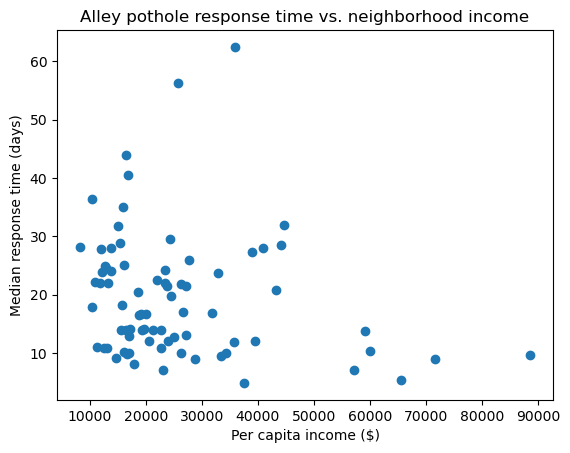

In [29]:
# Scatter of income vs. response time, one dot per community area.
# Visualizes the effect; the loose spread shows how much the trend leaves unexplained.

import matplotlib.pyplot as plt

plt.scatter(area['income'], area['median_response'])
plt.xlabel('Per capita income ($)')
plt.ylabel('Median response time (days)')
plt.title('Alley pothole response time vs. neighborhood income')
plt.show()

In [30]:
plt.savefig('scatter_income_vs_response.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

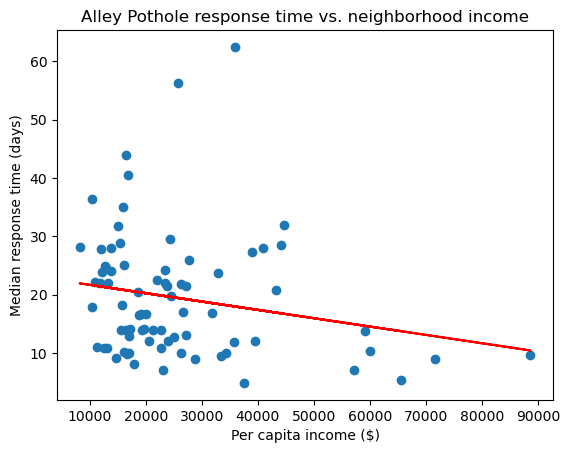

In [31]:
# Same scatter with a best-fit line (np.polyfit degree 1 = straight line).
# The downward slope is the direction of the association; the scatter shows how weak it is

import matplotlib.pyplot as plt
import numpy as np

plt.scatter(area['income'], area['median_response'])

x = area['income']
y = area['median_response']
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red')

plt.xlabel('Per capita income ($)')
plt.ylabel('Median response time (days)')
plt.title('Alley Pothole response time vs. neighborhood income')

plt.savefig('scatter_income_vs_response.png', dpi=150, bbox_inches='tight')  # save FIRST
plt.show()   # show AFTER

In [32]:
# Attach community-area NAMES from the income file so chart labels read as neighborhoods, not numbers.

names = income[['community_area', 'COMMUNITY AREA NAME']].rename(
    columns={'community_area': 'COMMUNITY_AREA'})
area_named = area.reset_index().merge(names, on='COMMUNITY_AREA', how='left').set_index('COMMUNITY AREA NAME')

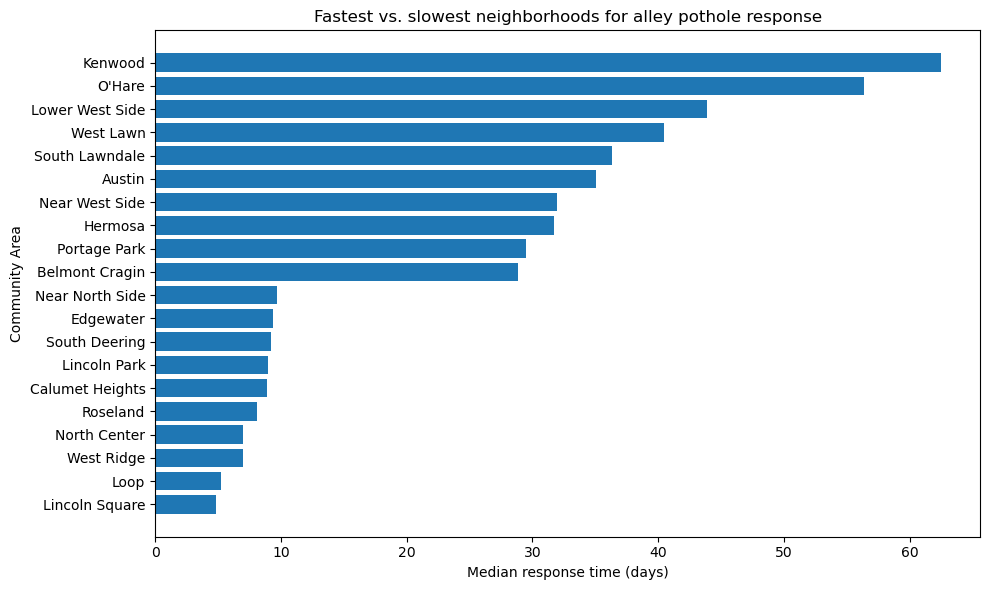

In [33]:
# Horizontal bar chart of the 10 fastest + 10 slowest neighborhoods -- shows the raw ~13x gap.
# barh keeps the neighborhood names readable.

combined = pd.concat([
    area_named.sort_values('median_response').head(10),
    area_named.sort_values('median_response').tail(10)
])

plt.figure(figsize=(10, 6))
plt.barh(combined.index.astype(str), combined['median_response'])
plt.xlabel('Median response time (days)')
plt.ylabel('Community Area')
plt.title('Fastest vs. slowest neighborhoods for alley pothole response')
plt.tight_layout()
plt.savefig('bar_fastest_slowest.png', dpi=150, bbox_inches='tight')
plt.show()

At the city-wide level there's a weak trend lower-income areas wait modestly longer (the scatter and regression show it). But the extreme cases are driven by other factors: O'Hare is an airport, some slow areas are gentrified, some fast ones are disadvantaged. So income is a at most a weak signal, and neighborhood-specific factors land use, infrastructure, request volume — matter more. The data supports a a weak, non-significant association, not a clean inequality narrative.

In [34]:
import statsmodels.api as sm

# Refit the income + volume model using statsmodels instead of sklearn.
# sklearn gave a coefficient and R^2 but no inference; statsmodels adds
# p-values and confidence intervals, which tell me whether the income
# effect is statistically distinguishable from zero given only 77 areas.

X = area[['income', 'volume']]
X = sm.add_constant(X)   # add an intercept column; statsmodels doesn't add one automatically (sklearn did)
y = area['median_response']

# OLS = ordinary least squares: the same linear regression as before,
# from a library that reports the full statistical summary.
model = sm.OLS(y, X).fit()

print(model.summary())   # coefficients, p-values, confidence intervals, R^2

                            OLS Regression Results                            
Dep. Variable:        median_response   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     1.642
Date:                Wed, 30 Sep 2026   Prob (F-statistic):              0.201
Time:                        16:54:28   Log-Likelihood:                -290.12
No. Observations:                  77   AIC:                             586.2
Df Residuals:                      74   BIC:                             593.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         22.7271      2.660      8.543      0.0

low p value (under 0.05) -> the pattern is real and unlikely to be luck
high p-value -> pattern might be luck 

In [35]:
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# Standardize predictors so income and volume are on the same scale
# (mean 0, sd 1). Fixes the scale mismatch behind the condition-number
# warning and makes the two coefficients directly comparable.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(area[['income', 'volume']])

X_scaled = sm.add_constant(X_scaled)
y = area['median_response']

model_scaled = sm.OLS(y, X_scaled).fit()
print(model_scaled.summary())

                            OLS Regression Results                            
Dep. Variable:        median_response   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     1.642
Date:                Wed, 30 Sep 2026   Prob (F-statistic):              0.201
Time:                        16:54:28   Log-Likelihood:                -290.12
No. Observations:                  77   AIC:                             586.2
Df Residuals:                      74   BIC:                             593.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         19.4348      1.218     15.962      0.0

Richer neighborhoods have slightly shorter wait times, but the income effect is not statistically significant (p = 0.075; the confidence interval includes zero). Volume isn't significant either (p = 0.758). Before de-duplication this was significant (p = 0.022), so the finding depends on removing duplicate reports.

In [36]:
import geopandas as gpd

areas_map = gpd.read_file("Boundaries.geojson")
print(areas_map.shape)
areas_map.head()

(77, 10)


,:id,:version,:created_at,:updated_at,area_numbe,community,area_num_1,shape_area,shape_len,geometry
0,row-m77e_pkv8.vjvf,rv-3hjp_vkhx~fqfx,2025-04-22 23:06:36.944000+00:00,2025-04-22 23:06:36.944000+00:00,1,ROGERS PARK,1,51259902.4506,34052.3975757,"MULTIPOLYGON (((-87.65456 41.99817, -87.65574 ..."
1,row-u375_347e-y6q8,rv-tgcx_t7fr-nkkg,2025-04-22 23:06:36.944000+00:00,2025-04-22 23:06:36.944000+00:00,2,WEST RIDGE,2,98429094.8621,43020.6894583,"MULTIPOLYGON (((-87.68465 42.01948, -87.68464 ..."
2,row-kgqf-m29p-99kg,rv-bag4-8zri.nvhu,2025-04-22 23:06:36.944000+00:00,2025-04-22 23:06:36.944000+00:00,3,UPTOWN,3,65095642.7289,46972.7945549,"MULTIPOLYGON (((-87.64102 41.9548, -87.644 41...."
3,row-2dpv_pk9x-zybp,rv-82s2~rb54~emuc,2025-04-22 23:06:36.944000+00:00,2025-04-22 23:06:36.944000+00:00,4,LINCOLN SQUARE,4,71352328.2399,36624.6030848,"MULTIPOLYGON (((-87.67441 41.9761, -87.6744 41..."
4,row-37zy.7r75.56p7,rv-hrse.ahu7-rz4d,2025-04-22 23:06:36.944000+00:00,2025-04-22 23:06:36.944000+00:00,5,NORTH CENTER,5,57054167.85,31391.6697542,"MULTIPOLYGON (((-87.67336 41.93234, -87.67342 ..."


In [37]:
# Convert the area number from text to integer so it matches my data's key.
areas_map['area_numbe'] = areas_map['area_numbe'].astype(int)

# Attach my per-area data (response time, income, volume) onto each polygon
# by matching community-area number. Left join keeps all 77 map areas.
geo = areas_map.merge(
    area.reset_index(),
    left_on='area_numbe',
    right_on='COMMUNITY_AREA',
    how='left'
)

# Verify the join worked: 0 nulls means every map area found its response-time data.
print(geo.shape)
print(geo['median_response'].isnull().sum())


(77, 15)
0


In [38]:
from libpysal.weights import Queen

# Build a spatial weights object: for each community area, find which other
# areas physically touch it. "Queen" contiguity counts areas as neighbors if
# they share any border or corner. This encodes the geography the regression ignored.
w = Queen.from_dataframe(geo, use_index=False)
w.transform = 'r'   # row-standardize: turn neighbor relationships into averages

In [39]:
import numpy as np
from esda.moran import Moran

np.random.seed(42)
# Moran's I tests whether nearby areas have similar response times.
# Positive + significant = response times cluster geographically (neighbors are alike),
# which means the areas aren't independent — the assumption my regression relied on.
mi = Moran(geo['median_response'], w)

print("Moran's I:", mi.I)       
print("p-value:", mi.p_sim)     

Moran's I: 0.27574267092901034
p-value: 0.001


I tested for spatial autocorrelation (Moran's I = 0.28, p < 0.01) and found response times cluster geographically — neighboring community areas have similar wait times. This means the areas aren't fully independent, so my regression's standard errors are likely slightly optimistic. Since the income association was already not significant, this makes it weaker still. A spatial regression model would be the proper next step.

In [40]:
geo.columns

Index([':id', ':version', ':created_at', ':updated_at', 'area_numbe',
       'community', 'area_num_1', 'shape_area', 'shape_len', 'geometry',
       'COMMUNITY_AREA', 'median_response', 'income', 'hardship', 'volume'],
      dtype='object')

In [41]:
# Keep only what the dashboard needs; drop the boundary-file junk (:id, area_num_1, etc.)
geo_clean = geo[['community', 'median_response', 'income', 'hardship', 'volume', 'geometry']]

In [42]:
geo_clean = geo_clean.copy()   # avoids a pandas warning
geo_clean['community'] = geo_clean['community'].str.title()   # ROGERS PARK -> Rogers Park

In [43]:
geo.shape

(77, 15)

In [44]:
geo_clean.to_file("chicago_potholes.geojson", driver="GeoJSON")

import os
print("chicago_potholes.geojson" in os.listdir())

True


In [45]:
df['SR_SHORT_CODE'].value_counts()

SR_SHORT_CODE
PHB    53878
Name: count, dtype: int64

In [46]:
area_named.sort_values('median_response')['median_response'].iloc[[0, -1]]

COMMUNITY AREA NAME
Lincoln Square     4.837593
Kenwood           62.480503
Name: median_response, dtype: float64